In [95]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [96]:
# !/Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13 -m pip install tqdm
# import sys
# print("Python:", sys.executable)

# test = pd.read_csv("/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/train_labels.csv")
# test.shape

# os.getcwd()

In [97]:
# ====================== Configuration ======================
class Config:
    # Paths - adjust these to your Kaggle dataset paths
    TRAIN_DIR = '/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/train/'
    TEST_DIR = '/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/test/'
    TRAIN_LABELS = '/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/train_labels.csv'
    
    # Model parameters
    IMG_SIZE = 96  # PCam images are 96x96
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 0.001
    NUM_WORKERS = 0
    
    # ResNet model
    RESNET_MODEL = 'resnet34'  # Options: resnet18, resnet34, resnet50
    PRETRAINED = True
    
    # Training
    VALIDATION_SPLIT = 0.2
    RANDOM_STATE = 42

config = Config()



In [47]:
# ====================== Dataset Class ======================
class CancerDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, f'{img_id}.tif')
        
        image = Image.open(img_path)
        
        if self.transform:
            image = self.transform(image)
        
        if self.is_test:
            return image, img_id
        else:
            label = self.df.iloc[idx]['label']
            return image, label



In [98]:
# ====================== Data Augmentation ======================
train_transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    # transforms.RandomRotation(20),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])



In [99]:
# ====================== Load Data ======================
print("Loading data...")
train_df = pd.read_csv(config.TRAIN_LABELS)
print(f"Total training samples: {len(train_df)}")
print(f"Label distribution:\n{train_df['label'].value_counts()}")

# Split data
train_data, val_data = train_test_split(
    train_df, 
    test_size=config.VALIDATION_SPLIT, 
    random_state=config.RANDOM_STATE,
    stratify=train_df['label']
)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Create datasets
train_dataset = CancerDataset(train_data, config.TRAIN_DIR, transform=train_transform)
val_dataset = CancerDataset(val_data, config.TRAIN_DIR, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=True, 
    # num_workers=config.NUM_WORKERS
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=False, 
    # num_workers=config.NUM_WORKERS
    num_workers=0
)



Loading data...
Total training samples: 17601
Label distribution:
label
0    10472
1     7129
Name: count, dtype: int64
Training samples: 14080
Validation samples: 3521


In [50]:
# ====================== Model Definition ======================
def get_resnet_model(model_name='resnet34', pretrained=True):
    """Create ResNet model"""
    if model_name == 'resnet18':
        model = models.resnet18(pretrained=pretrained)
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=pretrained)
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    # Modify the final layer for binary classification
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 1)
    
    return model

model = get_resnet_model(config.RESNET_MODEL, config.PRETRAINED)
model = model.to(device)
print(f"\nModel: {config.RESNET_MODEL}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")




Model: resnet34
Total parameters: 21,285,185


In [100]:
# ====================== Training Setup ======================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

In [101]:
# ====================== Training Functions ======================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.float().to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images = images.to(device)
            labels = labels.float().to(device).unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc



In [ ]:
# ====================== Training Loop ======================
print("\n" + "="*50)
print("Starting Training")
print("="*50)

best_auc = 0.0
train_losses = []
val_losses = []
train_aucs = []
val_aucs = []

for epoch in range(config.EPOCHS):
    print(f'\nEpoch {epoch+1}/{config.EPOCHS}')
    print('-' * 50)
    
    # Train
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    
    # Validate
    val_loss, val_auc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    print(f'Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}')
    
    # Learning rate scheduling
    scheduler.step(val_auc)
    
    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), 'best_resnet_model.pth')
        print(f'✓ Saved best model with AUC: {best_auc:.4f}')

print(f'\n{"="*50}')
print(f'Training Complete! Best Validation AUC: {best_auc:.4f}')
print("="*50)




Starting Training

Epoch 1/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [02:48<00:00,  3.00s/it]


Train Loss: 0.1796, Train AUC: 0.9782
Val Loss: 0.3631, Val AUC: 0.9380
✓ Saved best model with AUC: 0.9380

Epoch 2/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [03:09<00:00,  3.38s/it]


Train Loss: 0.1405, Train AUC: 0.9867
Val Loss: 0.4068, Val AUC: 0.9292

Epoch 3/15
--------------------------------------------------


...

Validation: 100%|███████████████████████████████| 56/56 [02:27<00:00,  2.64s/it]


Train Loss: 0.0429, Train AUC: 0.9986
Val Loss: 0.6074, Val AUC: 0.9179

Epoch 6/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [02:28<00:00,  2.65s/it]


Train Loss: 0.0333, Train AUC: 0.9991
Val Loss: 0.5705, Val AUC: 0.9308

Epoch 7/15
--------------------------------------------------


Training:  10%|█▉                | 23/220 [01:28<13:05,  3.99s/it, loss=0.00965]

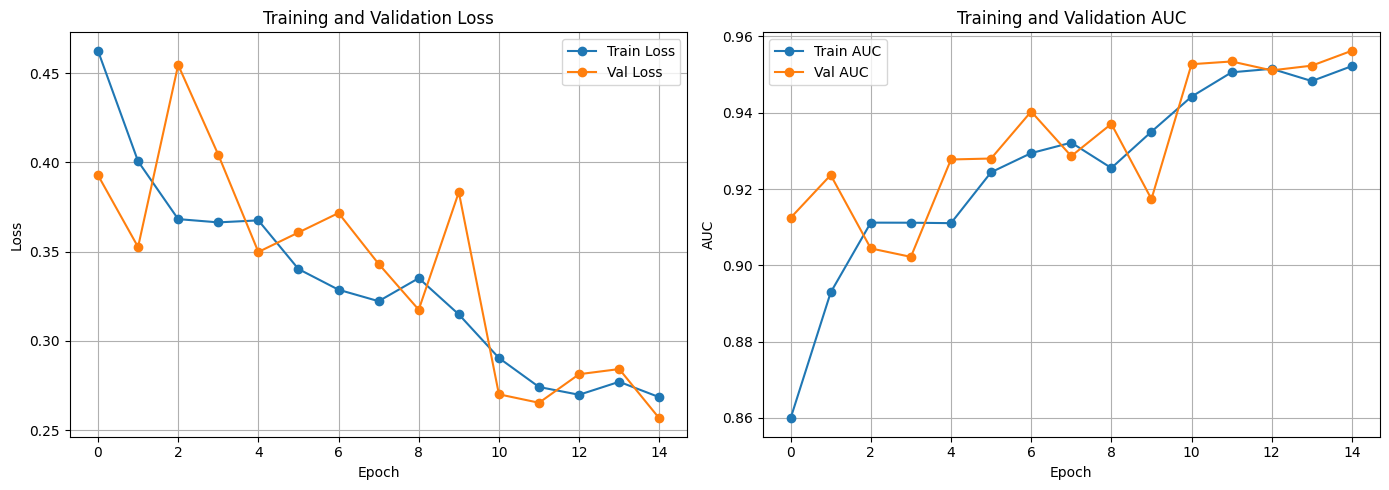

In [54]:
# ====================== Plot Training History ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# AUC plot
ax2.plot(train_aucs, label='Train AUC', marker='o')
ax2.plot(val_aucs, label='Val AUC', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_title('Training and Validation AUC')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()



In [62]:
# ====================== Generate Predictions ======================
print("\nGenerating predictions for test set...")

# Load test data
test_df = pd.read_csv('/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/test_labels.csv')
test_dataset = CancerDataset(test_df, config.TEST_DIR, transform=val_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model
model.load_state_dict(torch.load('best_resnet_model.pth'))
model.eval()

predictions = []
img_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
        predictions.extend(probs.flatten())
        img_ids.extend(ids)

# Create submission
submission = pd.DataFrame({
    'id': img_ids,
    'label': predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\n✓ Submission file created: submission.csv")
print(f"Total predictions: {len(submission)}")
print(f"\nSample predictions:")
print(submission.head(10))
print(f"\nPrediction statistics:")
print(submission['label'].describe())




Generating predictions for test set...


Predicting: 100%|███████████████████████████████| 69/69 [00:25<00:00,  2.69it/s]


✓ Submission file created: submission.csv
Total predictions: 4401

Sample predictions:
                                         id         label
0  c0596dc779612db5477d6a2e3770d61732c202e7  7.992043e-01
1  13682039e848c6e473c54619365b23ffcab50e2c  9.997335e-01
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9  2.251888e-02
3  540ee2788f05d170ab314cf30e5227275b9e1a3d  6.223752e-03
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f  2.057773e-01
5  210bf8072d6de21baea1ac55e2834fd4d876d23d  5.235757e-02
6  f1efb3d8a77418dc8aadb3951d2d346e9a13723b  2.390132e-01
7  53890a35991d4838a4252e79ed02680ab9a3197a  2.395889e-02
8  fa7878f602b852135b3bf617572907b98f5c2854  9.981964e-01
9  4720370a3fcc8a23879892589af34b53d848629b  9.529129e-10

Prediction statistics:
count    4.401000e+03
mean     4.196411e-01
std      4.191442e-01
min      1.345915e-13
25%      2.795761e-02
50%      1.985331e-01
75%      9.503686e-01
max      9.999998e-01
Name: label, dtype: float64



Visualizing sample predictions...


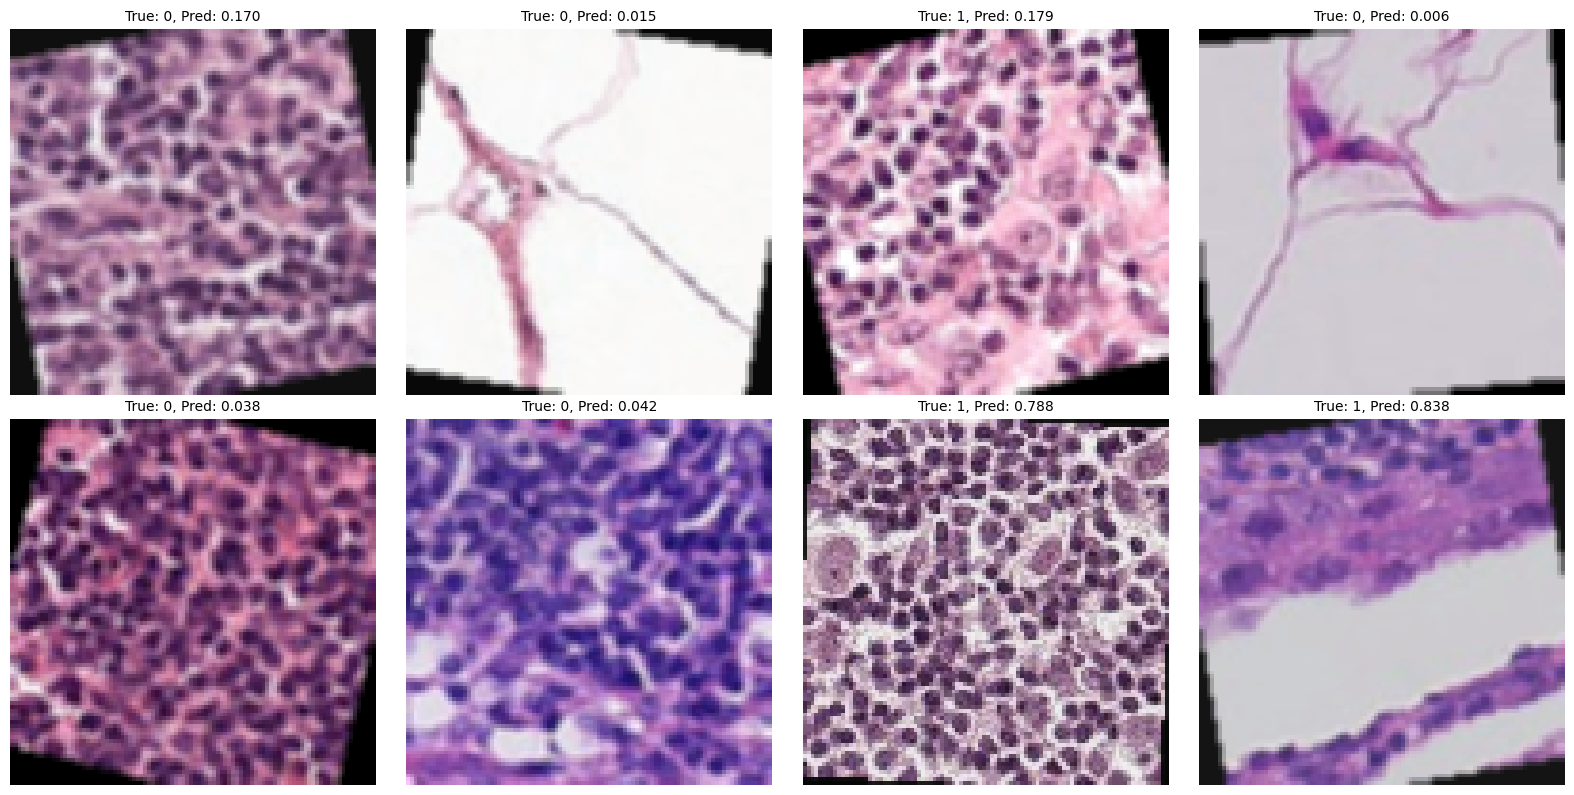


All done! Files created:
  - best_resnet_model.pth (model weights)
  - submission.csv (predictions)
  - training_history.png (training plots)
  - sample_predictions.png (sample results)


In [63]:
# ====================== Visualize Sample Predictions ======================
def show_predictions(model, dataset, device, num_samples=8):
    model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, label = dataset[idx]
            
            # Get prediction
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            pred_prob = torch.sigmoid(output).item()
            
            # Denormalize image for display
            img_display = image.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)
            
            ax.imshow(img_display)
            ax.set_title(f'True: {label}, Pred: {pred_prob:.3f}', fontsize=10)
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nVisualizing sample predictions...")
show_predictions(model, val_dataset, device)

print("\n" + "="*50)
print("All done! Files created:")
print("  - best_resnet_model.pth (model weights)")
print("  - submission.csv (predictions)")
print("  - training_history.png (training plots)")
print("  - sample_predictions.png (sample results)")
print("="*50)

# ResNet 50

In [84]:
# ====================== Configuration ======================
class Config:
    # Paths - adjust these to your Kaggle dataset paths
    TRAIN_DIR = '/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/train/'
    TEST_DIR = '/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/test/'
    TRAIN_LABELS = '/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/train_labels.csv'
    
    # Model parameters
    IMG_SIZE = 96  # PCam images are 96x96
    BATCH_SIZE = 64
    EPOCHS = 15
    LEARNING_RATE = 0.001
    NUM_WORKERS = 0
    
    # ResNet model
    RESNET_MODEL = 'resnet50'  # Options: resnet100, resnet34, resnet50
    PRETRAINED = True
    
    # Training
    VALIDATION_SPLIT = 0.2
    RANDOM_STATE = 42

config = Config()



In [85]:
# ====================== Dataset Class ======================
class CancerDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, f'{img_id}.tif')
        
        image = Image.open(img_path)
        
        if self.transform:
            image = self.transform(image)
        
        if self.is_test:
            return image, img_id
        else:
            label = self.df.iloc[idx]['label']
            return image, label



In [86]:
# ====================== Data Augmentation ======================
train_transform = transforms.Compose([
    # transforms.RandomHorizontalFlip(p=0.5),
    # transforms.RandomVerticalFlip(p=0.5),
    # transforms.RandomRotation(20),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                       std=[0.229, 0.224, 0.225])
])



In [87]:
# ====================== Load Data ======================
print("Loading data...")
train_df = pd.read_csv(config.TRAIN_LABELS)
print(f"Total training samples: {len(train_df)}")
print(f"Label distribution:\n{train_df['label'].value_counts()}")

# Split data
train_data, val_data = train_test_split(
    train_df, 
    test_size=config.VALIDATION_SPLIT, 
    random_state=config.RANDOM_STATE,
    stratify=train_df['label']
)

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Create datasets
train_dataset = CancerDataset(train_data, config.TRAIN_DIR, transform=train_transform)
val_dataset = CancerDataset(val_data, config.TRAIN_DIR, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=True, 
    # num_workers=config.NUM_WORKERS
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=config.BATCH_SIZE, 
    shuffle=False, 
    # num_workers=config.NUM_WORKERS
    num_workers=0
)



Loading data...
Total training samples: 17601
Label distribution:
label
0    10472
1     7129
Name: count, dtype: int64
Training samples: 14080
Validation samples: 3521


In [88]:
# ====================== Model Definition ======================
def get_resnet_model(model_name='resnet34', pretrained=True):
    """Create ResNet model"""
    if model_name == 'resnet101':
        model = models.resnet101(pretrained=pretrained)
    elif model_name == 'resnet34':
        model = models.resnet34(pretrained=pretrained)
    elif model_name == 'resnet50':
        model = models.resnet50(pretrained=pretrained)
    elif model_name == 'resnet152':
        model = models.resnet152(pretrained=pretrained)
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    # Modify the final layer for binary classification
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 1)
    
    return model

model = get_resnet_model(config.RESNET_MODEL, config.PRETRAINED)
model = model.to(device)
print(f"\nModel: {config.RESNET_MODEL}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")




Model: resnet50
Total parameters: 23,510,081


In [89]:
# ====================== Training Setup ======================
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

In [90]:
# ====================== Training Functions ======================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.float().to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        probs = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images = images.to(device)
            labels = labels.float().to(device).unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_preds)
    
    return epoch_loss, epoch_auc



In [91]:
# ====================== Training Loop ======================
print("\n" + "="*50)
print("Starting Training")
print("="*50)

best_auc = 0.0
train_losses = []
val_losses = []
train_aucs = []
val_aucs = []

for epoch in range(config.EPOCHS):
    print(f'\nEpoch {epoch+1}/{config.EPOCHS}')
    print('-' * 50)
    
    # Train
    train_loss, train_auc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    
    # Validate
    val_loss, val_auc = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    val_aucs.append(val_auc)
    
    print(f'Train Loss: {train_loss:.4f}, Train AUC: {train_auc:.4f}')
    print(f'Val Loss: {val_loss:.4f}, Val AUC: {val_auc:.4f}')
    
    # Learning rate scheduling
    scheduler.step(val_auc)
    
    # Save best model
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), 'best_resnet_model.pth')
        print(f'✓ Saved best model with AUC: {best_auc:.4f}')

print(f'\n{"="*50}')
print(f'Training Complete! Best Validation AUC: {best_auc:.4f}')
print("="*50)




Starting Training

Epoch 1/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [02:21<00:00,  2.52s/it]


Train Loss: 0.4123, Train AUC: 0.8911
Val Loss: 0.6767, Val AUC: 0.8991
✓ Saved best model with AUC: 0.8991

Epoch 2/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [02:05<00:00,  2.25s/it]


Train Loss: 0.3314, Train AUC: 0.9266
Val Loss: 0.3631, Val AUC: 0.9082
✓ Saved best model with AUC: 0.9082

Epoch 3/15
--------------------------------------------------


...

Train Loss: 0.0128, Train AUC: 0.9999
Val Loss: 0.5891, Val AUC: 0.9324

Epoch 14/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [02:27<00:00,  2.64s/it]


Train Loss: 0.0052, Train AUC: 1.0000
Val Loss: 0.6533, Val AUC: 0.9329

Epoch 15/15
--------------------------------------------------


Validation: 100%|███████████████████████████████| 56/56 [02:45<00:00,  2.95s/it]

Train Loss: 0.0048, Train AUC: 1.0000
Val Loss: 0.6790, Val AUC: 0.9340

Training Complete! Best Validation AUC: 0.9378


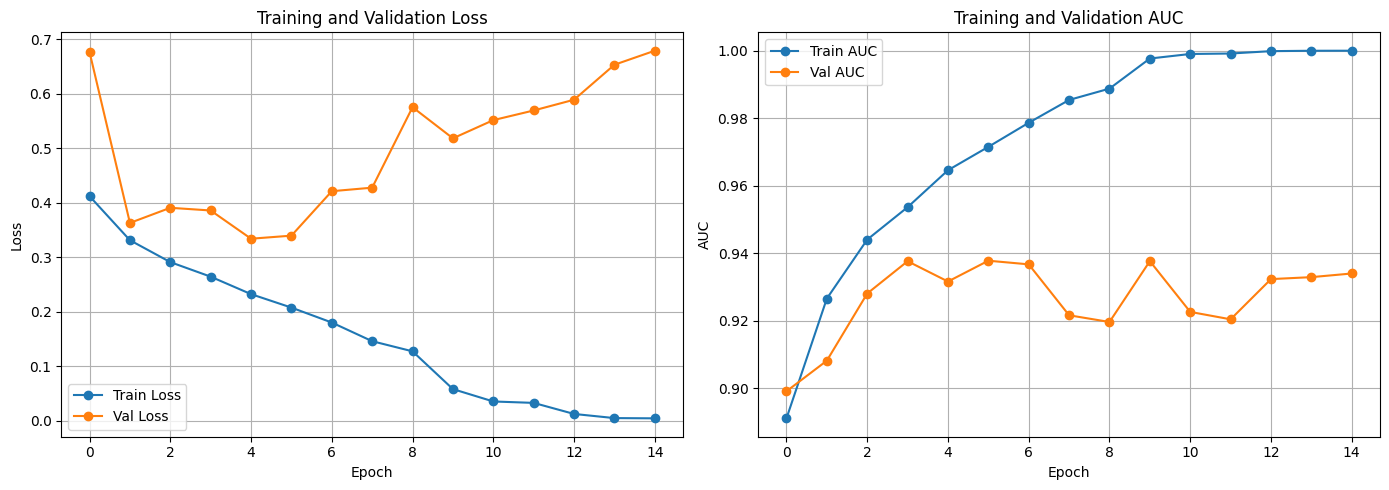

In [92]:
# ====================== Plot Training History ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses, label='Val Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# AUC plot
ax2.plot(train_aucs, label='Train AUC', marker='o')
ax2.plot(val_aucs, label='Val AUC', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.set_title('Training and Validation AUC')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()



In [93]:
# ====================== Generate Predictions ======================
print("\nGenerating predictions for test set...")

# Load test data
test_df = pd.read_csv('/Users/chung/Downloads/seminar_4/seminar_4/data/prepared_data/test_labels.csv')
test_dataset = CancerDataset(test_df, config.TEST_DIR, transform=val_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model
model.load_state_dict(torch.load('best_resnet_model.pth'))
model.eval()

predictions = []
img_ids = []

with torch.no_grad():
    for images, ids in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        
        predictions.extend(probs.flatten())
        img_ids.extend(ids)

# Create submission
submission = pd.DataFrame({
    'id': img_ids,
    'label': predictions
})

submission.to_csv('submission.csv', index=False)
print(f"\n✓ Submission file created: submission.csv")
print(f"Total predictions: {len(submission)}")
print(f"\nSample predictions:")
print(submission.head(10))
print(f"\nPrediction statistics:")
print(submission['label'].describe())




Generating predictions for test set...


Predicting: 100%|███████████████████████████████| 69/69 [03:26<00:00,  3.00s/it]


✓ Submission file created: submission.csv
Total predictions: 4401

Sample predictions:
                                         id     label
0  c0596dc779612db5477d6a2e3770d61732c202e7  0.242501
1  13682039e848c6e473c54619365b23ffcab50e2c  0.999841
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9  0.004172
3  540ee2788f05d170ab314cf30e5227275b9e1a3d  0.006975
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f  0.029600
5  210bf8072d6de21baea1ac55e2834fd4d876d23d  0.004357
6  f1efb3d8a77418dc8aadb3951d2d346e9a13723b  0.048907
7  53890a35991d4838a4252e79ed02680ab9a3197a  0.002608
8  fa7878f602b852135b3bf617572907b98f5c2854  0.999947
9  4720370a3fcc8a23879892589af34b53d848629b  0.001106

Prediction statistics:
count    4401.000000
mean        0.412060
std         0.439474
min         0.000058
25%         0.009102
50%         0.133887
75%         0.982985
max         1.000000
Name: label, dtype: float64



Visualizing sample predictions...


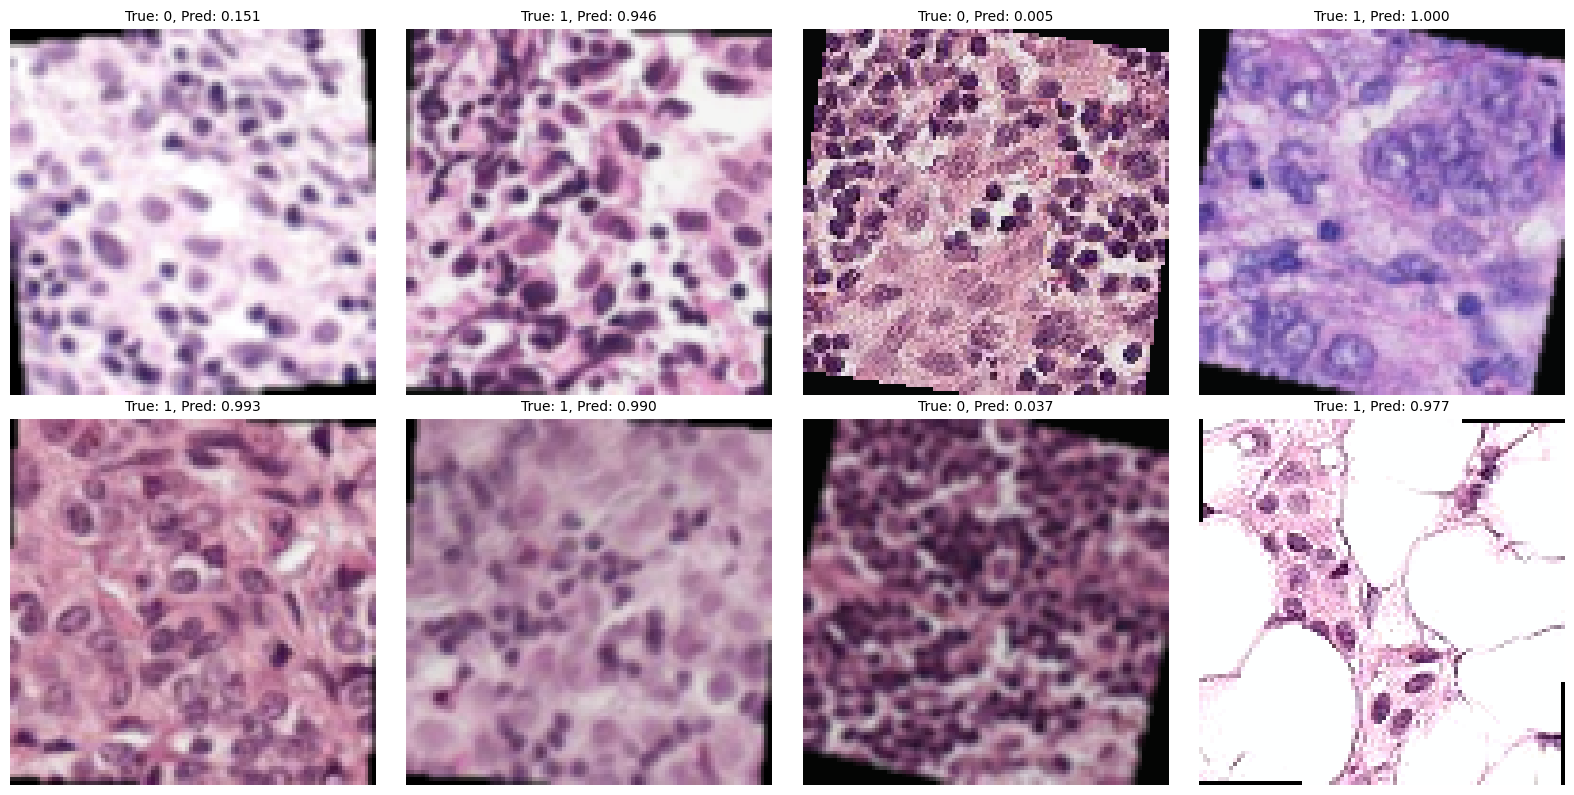


All done! Files created:
  - best_resnet_model.pth (model weights)
  - submission.csv (predictions)
  - training_history.png (training plots)
  - sample_predictions.png (sample results)


In [94]:
# ====================== Visualize Sample Predictions ======================
def show_predictions(model, dataset, device, num_samples=8):
    model.eval()
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for idx, ax in zip(indices, axes):
            image, label = dataset[idx]
            
            # Get prediction
            image_tensor = image.unsqueeze(0).to(device)
            output = model(image_tensor)
            pred_prob = torch.sigmoid(output).item()
            
            # Denormalize image for display
            img_display = image.permute(1, 2, 0).numpy()
            img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_display = np.clip(img_display, 0, 1)
            
            ax.imshow(img_display)
            ax.set_title(f'True: {label}, Pred: {pred_prob:.3f}', fontsize=10)
            ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nVisualizing sample predictions...")
show_predictions(model, val_dataset, device)

print("\n" + "="*50)
print("All done! Files created:")
print("  - best_resnet_model.pth (model weights)")
print("  - submission.csv (predictions)")
print("  - training_history.png (training plots)")
print("  - sample_predictions.png (sample results)")
print("="*50)